In [1]:
import fastparquet as fp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pathlib
from utils.plotting_helpers import file_to_qubit_mappings
import utils.make_paths_absolute

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)

In [2]:
file_to_qubit_count_mapping = file_to_qubit_mappings("intermediates/energy_mappings/alt_energies")

def get_files_by_folders(results_folders):
    result_paths = []
    for results_folder in results_folders:
        paths = list(pathlib.Path(f"{results_folder}").rglob("*.npz"))
        result_paths.extend(paths)

    return {path.as_posix().split("/")[-1].split(".")[0]: {"path": path} for path in result_paths}


def generate_df_from_files(result_files, file_to_qubit_count_mapping, target_confidence=0.9999):
    data_keys = ["cost_history", "target_probs", "target_indices", "best_target_index", "conformation_map"]

    for name, data in result_files.items():
        with open(data["path"], 'rb') as f:
            saved_results = np.load(f, allow_pickle=True)
            result_files[name]["data"] = {key: saved_results[key] for key in data_keys}

        result_files[name]["protein"] = name.split("_")[0]
        result_files[name]["start_residue"] = int(name.split("_")[1])
        result_files[name]["end_residue"] = int(name.split("_")[2])
        result_files[name]["rotamer_count"] = int(name.split("_")[3])
        result_files[name]["qaoa_layers"] = int(name.split("_")[4])

        result_files[name]["subsection"] = f"{result_files[name]['start_residue']}-{result_files[name]['end_residue']}"
        result_files[name]["subsection_length"] = result_files[name]["end_residue"] - result_files[name][
            "start_residue"] + 1

        name_without_layers = "_".join(name.split("_")[:-2])
        if name_without_layers in file_to_qubit_count_mapping:
            result_files[name]["num_qubits"] = file_to_qubit_count_mapping[name_without_layers]
        else:
            print(f"Warning: No qubit mapping found for {name_without_layers}. Setting num_qubits to None.")
            result_files[name]["num_qubits"] = None

    target_probs_records = []
    for name, data in result_files.items():
        # if not name.startswith("5PTI_18_22"): continue

        target_probs = result_files[name]["data"]['target_probs']
        # print("Shape of target_probs:", target_probs.shape)  # Should be (30, 16)

        # Sum across the 16 conformations for each seed
        summed_probs = target_probs.sum(axis=1)  # Shape becomes (30,)
        # print("Shape after summing across conformations:", summed_probs.shape)

        # Create a record for each seed with its summed probability
        for seed_idx, summed_prob in enumerate(summed_probs):
            if int(summed_prob) == 1:
                shots_for_target_prob = 1
            else:
                shots_for_target_prob = np.ceil(np.log(1 - target_confidence) / np.log(1 - summed_prob))
            record = {
                'protein': result_files[name]['protein'],
                'subsection': result_files[name]['subsection'],
                'subsection_length': result_files[name]['subsection_length'],
                'rotamer_count': result_files[name]['rotamer_count'],
                'qaoa_layers': result_files[name]['qaoa_layers'],
                'num_qubits': result_files[name]['num_qubits'],
                'seed': seed_idx,
                'target_prob': summed_prob,  # This is now the sum across all 16 conformations
                'shots_for_target_prob': shots_for_target_prob
            }
            target_probs_records.append(record)

    # Create dataframe from records
    return pd.DataFrame(target_probs_records)

In [3]:
colab_files = get_files_by_folders(["outputs/runs_before_round_robin_rotamers_param/QAOA_Results_Backup 2",
                                    "outputs/runs_before_round_robin_rotamers_param/QAOA_Results_Backup_3"])
colab_df = generate_df_from_files(colab_files, file_to_qubit_count_mapping)
colab_df = colab_df[colab_df['num_qubits'] >= 14]

local_files = get_files_by_folders(["outputs/runs_before_round_robin_rotamers_param/prev_in_qaoa/qaoa_runs_5-14_batch1",
                                    'outputs/runs_before_round_robin_rotamers_param/prev_in_qaoa/qaoa_runs_5-14_batch2'])
local_df = generate_df_from_files(local_files, file_to_qubit_count_mapping)
local_df = local_df[local_df['num_qubits'] <= 14]

combined_df = pd.concat([colab_df, local_df], ignore_index=True)

twelve_layer_df = combined_df[combined_df['qaoa_layers'] == 12]
twelve_layer_df

,protein,subsection,subsection_length,rotamer_count,qaoa_layers,num_qubits,seed,target_prob,shots_for_target_prob
0,5PTI,15-21,7,5,12,22,0,0.003191,2882.0
1,5PTI,15-21,7,5,12,22,1,0.026477,344.0
2,5PTI,15-21,7,5,12,22,2,0.017021,537.0
3,5PTI,15-21,7,5,12,22,3,0.069033,129.0
4,5PTI,15-21,7,5,12,22,4,0.523586,13.0
...,...,...,...,...,...,...,...,...,...
17105,5PTI,8-13,6,6,12,14,25,0.265041,30.0
17106,5PTI,8-13,6,6,12,14,26,0.716732,8.0
17107,5PTI,8-13,6,6,12,14,27,0.640423,10.0
17108,5PTI,8-13,6,6,12,14,28,0.840003,6.0


Fitted parameters: a=3.46e-01, b=3.14e-01


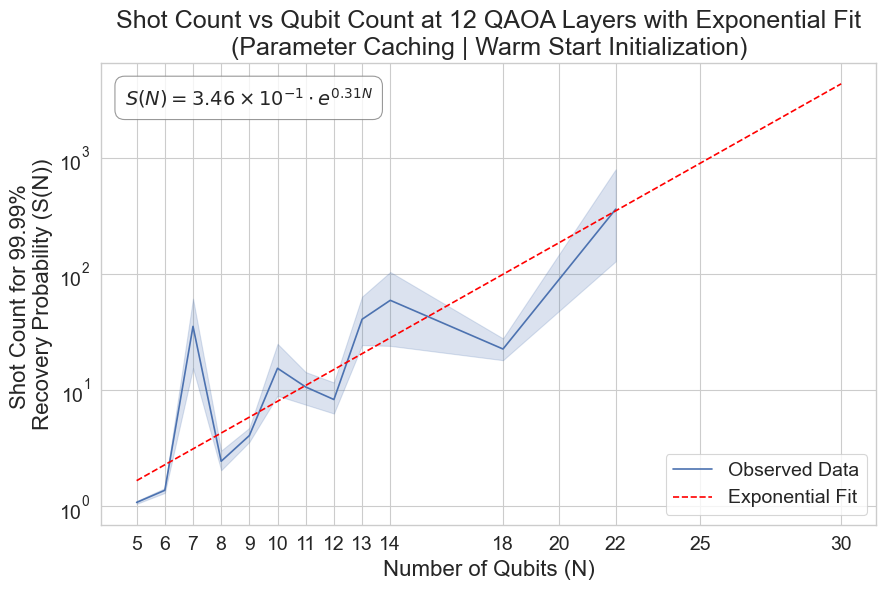

In [4]:

# Extrapolate the 12-layer curve to estimate shots for 30 qubits
from scipy.optimize import curve_fit


def exponential_model(x, a, b):
    return a * np.exp(b * x)


x_data = twelve_layer_df['num_qubits']
y_data = twelve_layer_df['shots_for_target_prob']

fit_result = curve_fit(exponential_model, x_data, y_data, p0=(1e3, 0.1))
popt = fit_result[0]
a, b = popt
print(f"Fitted parameters: a={a:.2e}, b={b:.2e}")
x_extrapolate = np.arange(5, 31)
y_extrapolate = exponential_model(x_extrapolate, a, b)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=twelve_layer_df,
             x="num_qubits", y="shots_for_target_prob",
             markers=True,
             ax=ax, label='Observed Data')
ax.plot(x_extrapolate, y_extrapolate, label='Exponential Fit', linestyle='--', color='red')

a_str = f"{a:.2e}"

# 2. Split it into the base number and the exponent
base, exponent = a_str.split('e')

# 3. Create a LaTeX formatted string (int(exponent) removes the leading zero)
a_latex = f"{base} \\times 10^{{{int(exponent)}}}"

# 4. Insert the clean scientific notation into the final equation
equation_text = f"$S(N) = {a_latex} \\cdot e^{{{b:.2f}N}}$"
# Place the text box in the upper left corner
ax.text(0.03, 0.95, equation_text, transform=ax.transAxes, fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

ax.set_title(
    "Shot Count vs Qubit Count at 12 QAOA Layers with Exponential Fit\n(Parameter Caching | Warm Start Initialization)",
    fontsize=18)
ax.set_xlabel("Number of Qubits (N)", fontsize=16)
ax.set_ylabel("Shot Count for 99.99% \nRecovery Probability (S(N))", fontsize=16)
ax.set_yscale('log')

xticks = sorted(twelve_layer_df['num_qubits'].unique())
xticks.extend([20, 25, 30])
ax.set_xticks(sorted(xticks))

ax.legend(fontsize=14)
ax.tick_params(axis="both", labelsize=14)

plt.savefig(f"publication_plots/combined_local_colab_shots_by_qubits_at_last_layer_with_fit.svg", dpi=300,
            bbox_inches='tight')
plt.show()

In [5]:
plot_df = twelve_layer_df.dropna(subset=["subsection"]).copy()

# 2. Extract the starting index from the 'subsection' column
# This splits the string "18-24" by "-" and takes the first element ("18"), converting it to an integer
plot_df["start_index"] = plot_df["subsection"].apply(lambda s: int(str(s).split("-")[0]))


def min_max_at_qubit(plot_df, qubit_count):
    subset = plot_df[plot_df['num_qubits'] == qubit_count]
    # Shots for target prob at 12 layers, grouped by subsection starting index
    grouped = subset.groupby('start_index')['shots_for_target_prob'].agg(['mean']).reset_index()

    min_of_group = grouped['mean'].min()
    max_of_group = grouped['mean'].max()
    max_over_min_ratio = max_of_group / min_of_group if min_of_group != 0 else float('inf')

    print(f"Qubit Count: {qubit_count} | Min Shots: {min_of_group:.2f} | Max Shots: {max_of_group:.2f} | Max/Min Ratio: {max_over_min_ratio:.2f}")

min_max_at_qubit(plot_df, 7)
min_max_at_qubit(plot_df, 12)
min_max_at_qubit(plot_df, 22)

Qubit Count: 7 | Min Shots: 1.10 | Max Shots: 84.27 | Max/Min Ratio: 76.61
Qubit Count: 12 | Min Shots: 3.40 | Max Shots: 24.80 | Max/Min Ratio: 7.29
Qubit Count: 22 | Min Shots: 52.53 | Max Shots: 732.88 | Max/Min Ratio: 13.95
